# 🛒 Global Superstore — Retail Sales Data Visualization
### *Focusing Audience Attention on Key Business Insights*

**Author:** Om Dipak Patil
**Dataset:** Global Superstore 2016 (51,290 orders, 2012–2015)  
**Tools:** Python, Pandas, Matplotlib, Seaborn, Plotly  
**Visualization Reference:** [datavizproject.com](https://datavizproject.com/)

---

### Story Arc
This notebook tells a business story in four acts:
1. **Overall Trend** — How has the business grown over time?
2. **Category Breakdown** — Which products drive profit?
3. **Regional Analysis** — Where is the business strongest?
4. **Discount & Profit Impact** — Does discounting hurt profitability?

---

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Global style
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')

# Brand color palette
C_BLUE   = '#2C6FED'   # primary highlight
C_ORANGE = '#F47F24'   # secondary highlight
C_RED    = '#E03434'   # negative / loss
C_GREEN  = '#27AE60'   # positive / profit
C_MUTED  = '#B0BEC5'   # muted / background
C_DARK   = '#263238'   # titles / labels

print("Libraries imported ")

Libraries imported 


---
## 2. Load & Prepare Data

In [3]:
df = pd.read_excel('global_superstore_2016.xlsx')

# ── Datetime conversion ──────────────────────────────────────────
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# ── Numeric columns (already numeric from Excel, ensure float) ───
for col in ['Sales', 'Profit', 'Shipping Cost', 'Quantity', 'Discount']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Derived columns ──────────────────────────────────────────────
df['Year']          = df['Order Date'].dt.year
df['YearMonth']     = df['Order Date'].dt.to_period('M')
df['Quarter']       = df['Order Date'].dt.to_period('Q')
df['Profit Margin'] = df['Profit'] / df['Sales'].replace(0, np.nan)
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# ── Drop rows with missing key values ───────────────────────────
df.dropna(subset=['Sales', 'Profit', 'Category'], inplace=True)

print(f"Dataset shape  : {df.shape}")
print(f"Date range     : {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"Total Sales    : ${df['Sales'].sum():,.0f}")
print(f"Total Profit   : ${df['Profit'].sum():,.0f}")
print(f"Overall Margin : {df['Profit'].sum()/df['Sales'].sum()*100:.1f}%")
print("\nSummary:")
print(df[['Sales','Profit','Discount','Quantity','Shipping Cost']].describe().round(2))

Dataset shape  : (51290, 29)
Date range     : 2012-01-01 → 2015-12-31
Total Sales    : $12,642,502
Total Profit   : $1,467,457
Overall Margin : 11.6%

Summary:
          Sales    Profit  Discount  Quantity  Shipping Cost
count  51290.00  51290.00  51290.00  51290.00       51290.00
mean     246.49     28.61      0.14      3.48          26.48
std      487.57    174.34      0.21      2.28          57.25
min        0.44  -6599.98      0.00      1.00           1.00
25%       30.76      0.00      0.00      2.00           2.61
50%       85.05      9.24      0.00      3.00           7.79
75%      251.05     36.81      0.20      5.00          24.45
max    22638.48   8399.98      0.85     14.00         933.57


---
# ACT 1 — Overall Trend

## Visualization 1 — Sales & Profit Trend Over Time
### Type: Area Chart *(datavizproject.com)*

**Design rationale:**  
An area chart emphasizes cumulative volume and the gap between two series. Using **contrasting colors** (blue for Sales, green for Profit) and a **filled region** between them immediately directs attention to the spread — how much of Sales revenue converts to Profit. Quarterly aggregation removes short-term noise and reveals the macro trend. Key years are annotated to anchor the viewer in time.

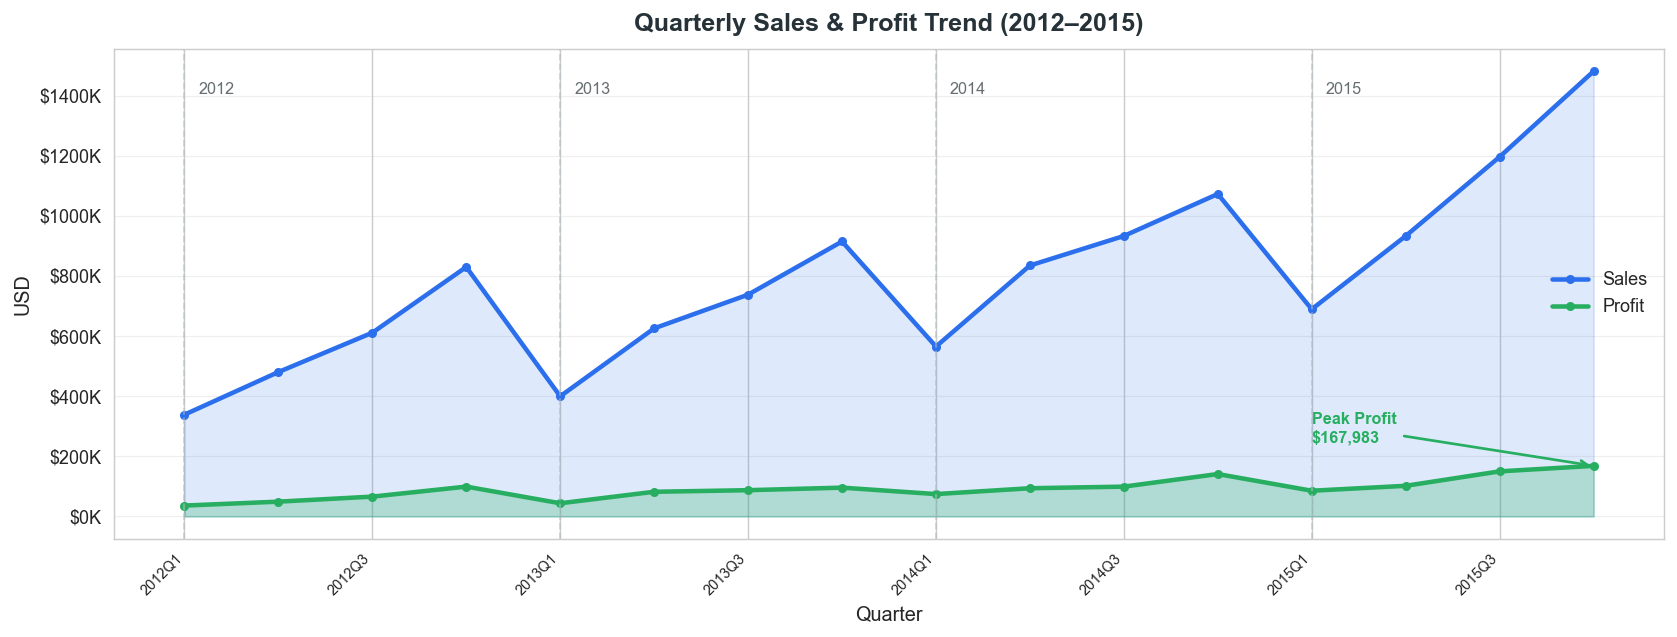

📌 Insight: Sales and profit both grow steadily, with a strong Q4 spike each year.


In [4]:
# Quarterly aggregation
quarterly = df.groupby('Quarter').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()
quarterly['Quarter_str'] = quarterly['Quarter'].astype(str)

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(range(len(quarterly)), quarterly['Sales'],
                alpha=0.15, color=C_BLUE)
ax.fill_between(range(len(quarterly)), quarterly['Profit'],
                alpha=0.25, color=C_GREEN)
ax.plot(range(len(quarterly)), quarterly['Sales'],
        color=C_BLUE, linewidth=2.5, label='Sales', marker='o', markersize=4)
ax.plot(range(len(quarterly)), quarterly['Profit'],
        color=C_GREEN, linewidth=2.5, label='Profit', marker='o', markersize=4)

# Annotate year boundaries
year_starts = [i for i, q in enumerate(quarterly['Quarter_str']) if 'Q1' in q]
for i, yi in enumerate(year_starts):
    year_label = quarterly['Quarter_str'].iloc[yi][:4]
    ax.axvline(yi, color=C_MUTED, linewidth=1, linestyle='--', alpha=0.6)
    ax.text(yi + 0.15, quarterly['Sales'].max() * 0.95,
            year_label, fontsize=9, color=C_DARK, alpha=0.7)

# Annotate peak profit quarter
peak_idx = quarterly['Profit'].idxmax()
ax.annotate(
    f"Peak Profit\n${quarterly['Profit'].iloc[peak_idx]:,.0f}",
    xy=(peak_idx, quarterly['Profit'].iloc[peak_idx]),
    xytext=(peak_idx - 3, quarterly['Profit'].iloc[peak_idx] + 80000),
    arrowprops=dict(arrowstyle='->', color=C_GREEN, lw=1.5),
    fontsize=9, color=C_GREEN, fontweight='bold'
)

ax.set_xticks(range(0, len(quarterly), 2))
ax.set_xticklabels(quarterly['Quarter_str'].iloc[::2], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Quarterly Sales & Profit Trend (2012–2015)',
             fontsize=14, fontweight='bold', color=C_DARK, pad=10)
ax.set_xlabel('Quarter', fontsize=11)
ax.set_ylabel('USD', fontsize=11)
ax.legend(fontsize=10, frameon=False)
ax.grid(True, axis='y', alpha=0.3, linewidth=0.7)

plt.tight_layout()
plt.savefig('viz1_trend.png', dpi=150)
plt.show()
print("📌 Insight: Sales and profit both grow steadily, with a strong Q4 spike each year.")

---
## Visualization 2 — Annual KPI Summary
### Type: Bar Chart *(datavizproject.com)*

**Design rationale:**  
Grouped bars allow year-over-year comparison of Sales vs Profit. The **size difference** between the blue and green bars immediately communicates the profit margin gap. Annotating the profit margin % on top of each profit bar focuses attention on the single most actionable metric — not just absolute profit, but efficiency.

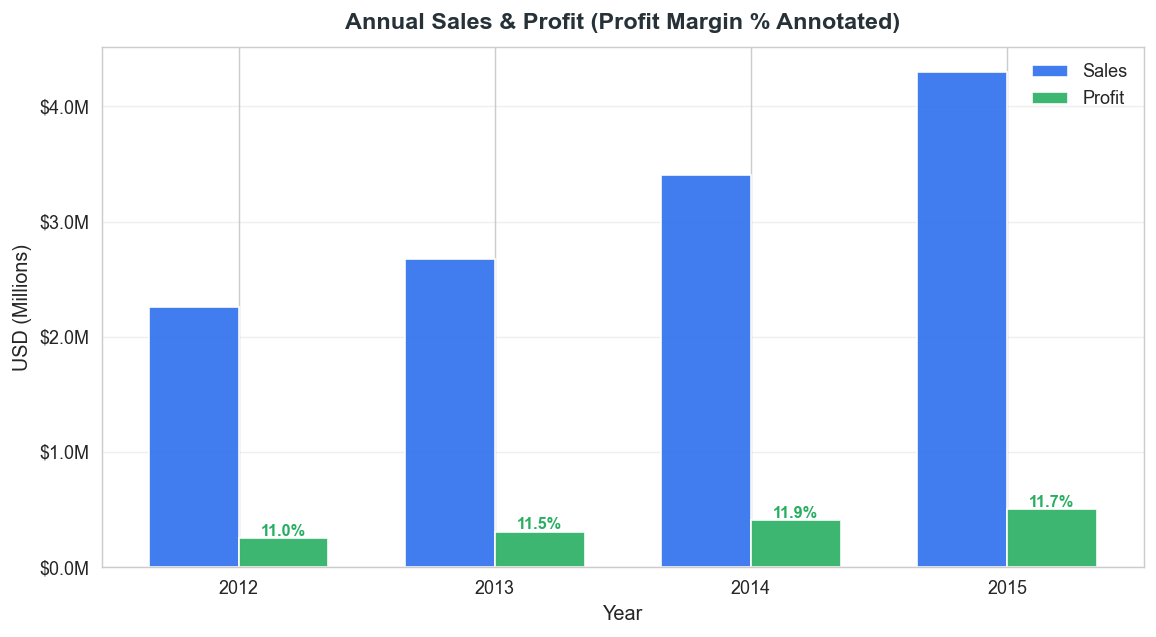

📌 Insight: Profit margin improved from ~11% in 2012 to ~12% in 2015 — a positive trend.


In [5]:
annual = df.groupby('Year').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum')
).reset_index()
annual['Margin'] = annual['Profit'] / annual['Sales'] * 100

x = np.arange(len(annual))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, annual['Sales']/1e6, w, color=C_BLUE,   label='Sales',  alpha=0.9)
b2 = ax.bar(x + w/2, annual['Profit']/1e6, w, color=C_GREEN, label='Profit', alpha=0.9)

# Annotate profit margin on profit bars
for bar, margin in zip(b2, annual['Margin']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{margin:.1f}%', ha='center', fontsize=9,
            fontweight='bold', color=C_GREEN)

ax.set_xticks(x)
ax.set_xticklabels(annual['Year'].astype(int))
ax.set_title('Annual Sales & Profit (Profit Margin % Annotated)',
             fontsize=13, fontweight='bold', color=C_DARK, pad=10)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('USD (Millions)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.legend(fontsize=10, frameon=False)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz2_annual_kpi.png', dpi=150)
plt.show()
print("📌 Insight: Profit margin improved from ~11% in 2012 to ~12% in 2015 — a positive trend.")

---
# ACT 2 — Category Breakdown

## Visualization 3 — Profit by Category
### Type: Lollipop Chart *(datavizproject.com)*

**Design rationale:**  
A lollipop chart is a decluttered alternative to a bar chart — the stem reduces ink while the dot draws the eye to the exact value. Using **green for profitable** and **red for loss-making** sub-categories applies the preattentive attribute of color to instantly classify performance. Sorting by profit value guides the viewer from best to worst without requiring axis reading.

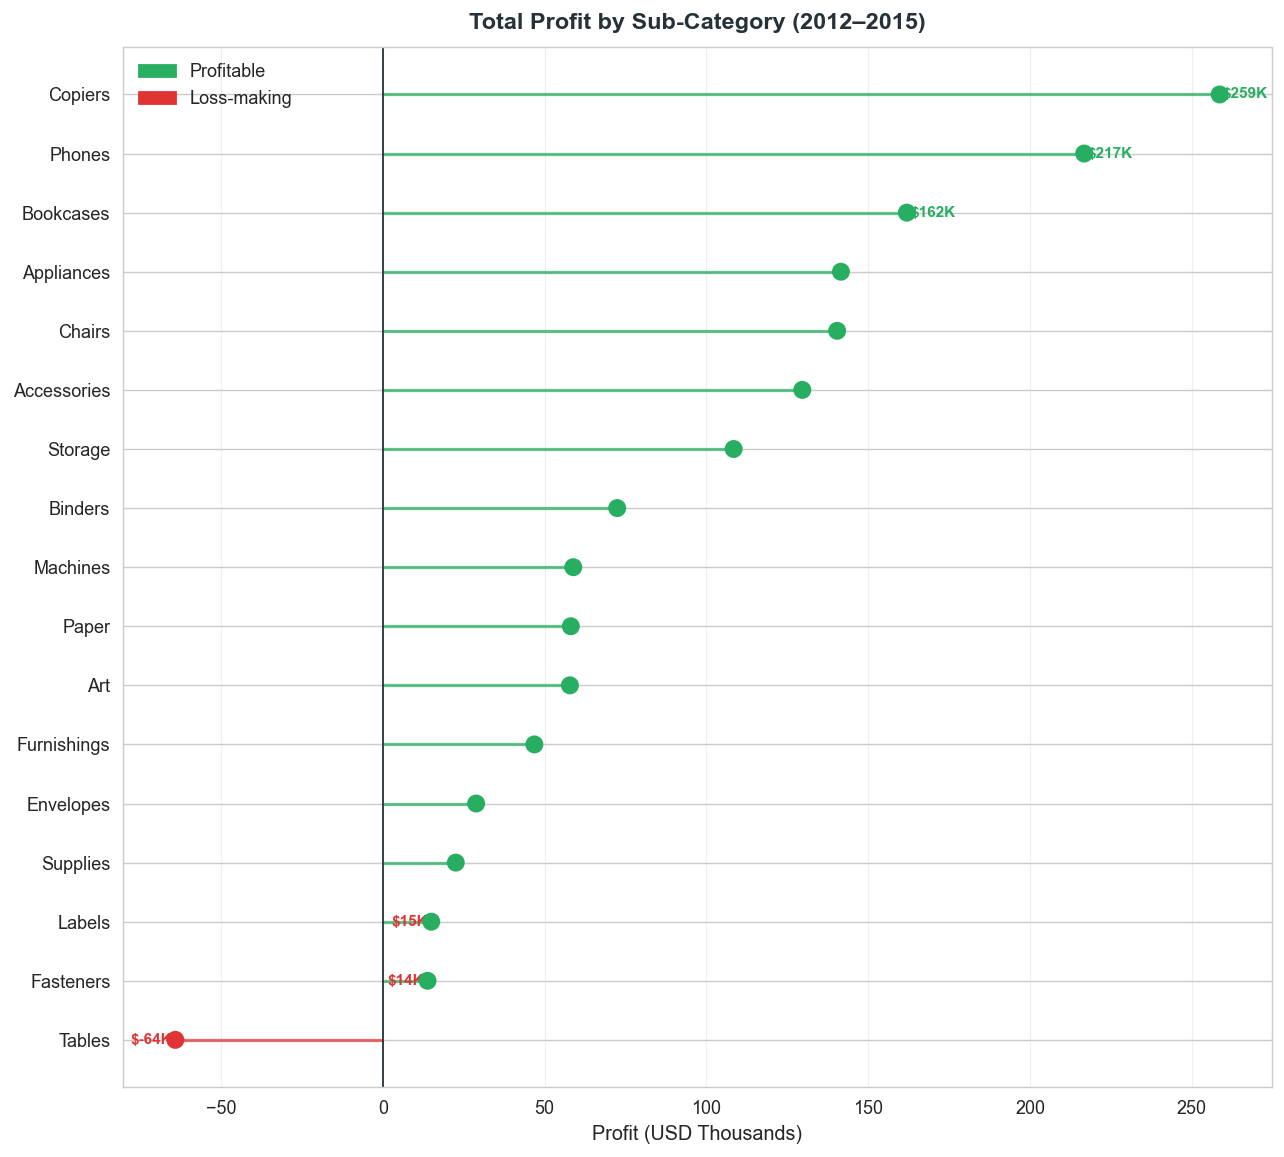

📌 Insight: Tables and Bookcases are loss-making. Copiers and Phones drive the most profit.


In [6]:
subcat_profit = df.groupby(['Category','Sub-Category']).agg(
    Profit=('Profit','sum'), Sales=('Sales','sum')
).reset_index().sort_values('Profit')

colors = [C_RED if p < 0 else C_GREEN for p in subcat_profit['Profit']]

fig, ax = plt.subplots(figsize=(10, 9))

ax.hlines(y=subcat_profit['Sub-Category'],
          xmin=0, xmax=subcat_profit['Profit']/1000,
          color=colors, linewidth=1.8, alpha=0.7)
ax.scatter(subcat_profit['Profit']/1000, subcat_profit['Sub-Category'],
           color=colors, s=80, zorder=5)

# Annotate worst and best
for _, row in subcat_profit.head(3).iterrows():
    ax.text(row['Profit']/1000 - 1, row['Sub-Category'],
            f"${row['Profit']/1000:.0f}K", va='center', ha='right',
            fontsize=8.5, color=C_RED, fontweight='bold')
for _, row in subcat_profit.tail(3).iterrows():
    ax.text(row['Profit']/1000 + 1, row['Sub-Category'],
            f"${row['Profit']/1000:.0f}K", va='center', ha='left',
            fontsize=8.5, color=C_GREEN, fontweight='bold')

ax.axvline(0, color=C_DARK, linewidth=1, linestyle='-')
ax.set_title('Total Profit by Sub-Category (2012–2015)',
             fontsize=13, fontweight='bold', color=C_DARK, pad=10)
ax.set_xlabel('Profit (USD Thousands)', fontsize=11)
ax.set_ylabel('')
ax.grid(True, axis='x', alpha=0.3, linewidth=0.7)

loss_patch   = mpatches.Patch(color=C_RED,   label='Loss-making')
profit_patch = mpatches.Patch(color=C_GREEN, label='Profitable')
ax.legend(handles=[profit_patch, loss_patch], fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig('viz3_lollipop.png', dpi=150)
plt.show()
print("📌 Insight: Tables and Bookcases are loss-making. Copiers and Phones drive the most profit.")

---
## Visualization 4 — Sales vs Profit by Sub-Category
### Type: Bubble Chart *(datavizproject.com)*

**Design rationale:**  
A bubble chart encodes **three variables simultaneously** — Sales (x-axis), Profit (y-axis), and Quantity (bubble size). The preattentive use of **position** (y-axis = profit) and **color** (category) allows instant identification of high-revenue/low-profit sub-categories — the "value traps" of the business. The zero-profit line divides winners from losers.

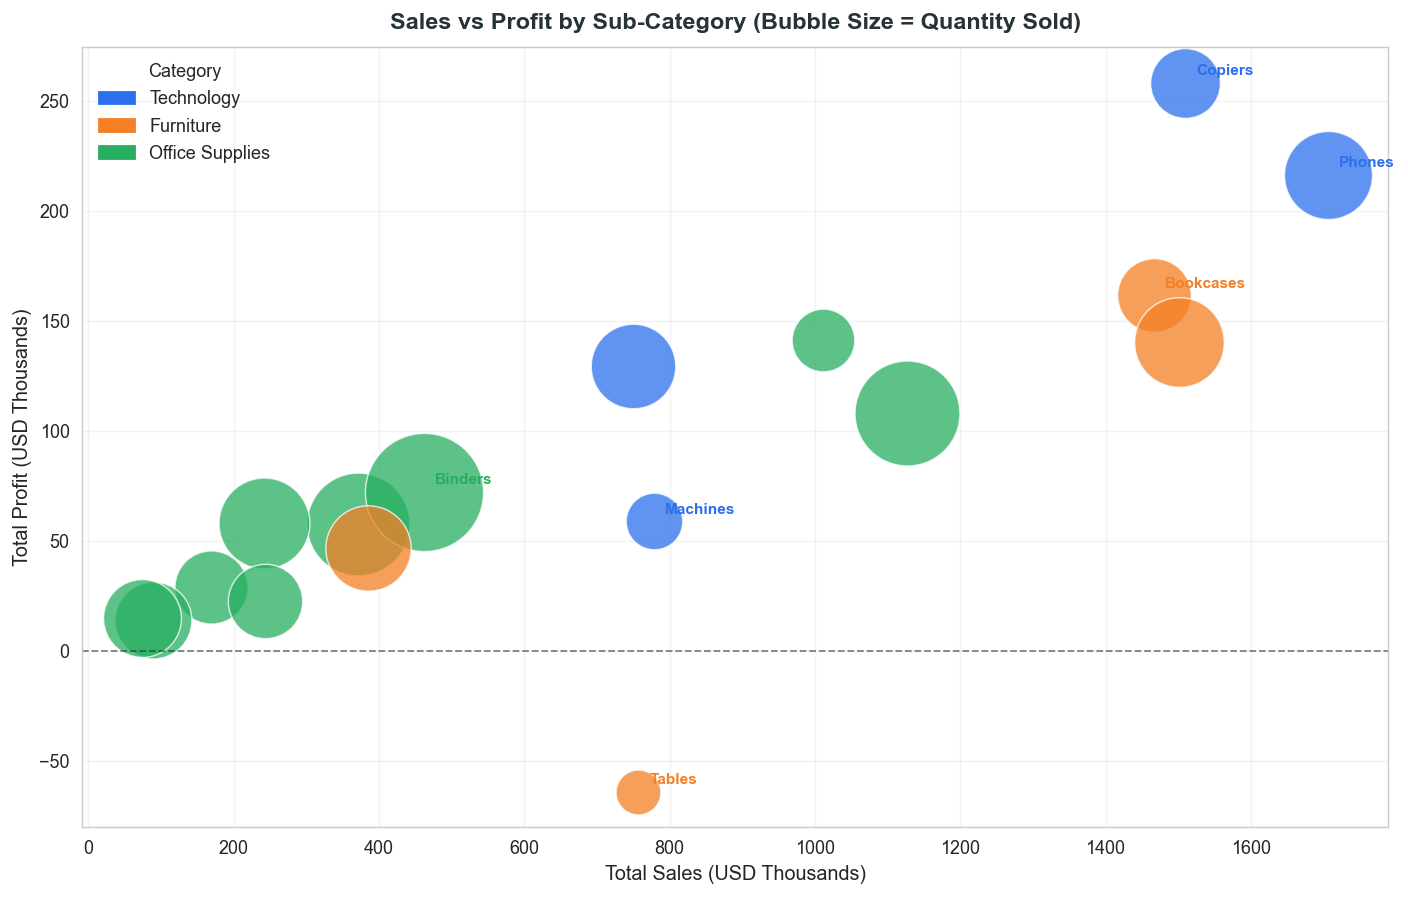

📌 Insight: Tables generate high sales but negative profit — a key red flag.
   Copiers have low volume but very high profitability.


In [7]:
bubble_data = df.groupby(['Sub-Category','Category']).agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Quantity=('Quantity','sum')
).reset_index()

cat_colors = {'Technology': C_BLUE, 'Furniture': C_ORANGE, 'Office Supplies': C_GREEN}
bubble_data['color'] = bubble_data['Category'].map(cat_colors)

fig, ax = plt.subplots(figsize=(11, 7))

for _, row in bubble_data.iterrows():
    ax.scatter(row['Sales']/1000, row['Profit']/1000,
               s=row['Quantity']/5,
               color=row['color'], alpha=0.75, edgecolors='white', linewidths=0.8)

# Label notable sub-categories
highlight = ['Copiers','Tables','Phones','Bookcases','Binders','Machines']
for _, row in bubble_data[bubble_data['Sub-Category'].isin(highlight)].iterrows():
    ax.annotate(row['Sub-Category'],
                (row['Sales']/1000, row['Profit']/1000),
                textcoords='offset points', xytext=(6, 4),
                fontsize=8.5, fontweight='bold',
                color=row['color'])

ax.axhline(0, color=C_DARK, linewidth=1, linestyle='--', alpha=0.6)
ax.set_title('Sales vs Profit by Sub-Category (Bubble Size = Quantity Sold)',
             fontsize=13, fontweight='bold', color=C_DARK, pad=10)
ax.set_xlabel('Total Sales (USD Thousands)', fontsize=11)
ax.set_ylabel('Total Profit (USD Thousands)', fontsize=11)
ax.grid(True, alpha=0.25)

# Legend for categories
legend_handles = [mpatches.Patch(color=v, label=k) for k, v in cat_colors.items()]
ax.legend(handles=legend_handles, fontsize=10, frameon=False, title='Category')

plt.tight_layout()
plt.savefig('viz4_bubble.png', dpi=150)
plt.show()
print("📌 Insight: Tables generate high sales but negative profit — a key red flag.")
print("   Copiers have low volume but very high profitability.")

---
## Visualization 5 — Profit by Category & Segment
### Type: Grouped Bar Chart *(datavizproject.com)*

**Design rationale:**  
Grouping by both Category and Segment reveals which customer segments are most profitable per category. The **consistent color per segment** across all categories allows the viewer to track a single segment's performance across categories without re-reading the legend. This directs attention to the **Technology + Consumer** combination as the top profit driver.

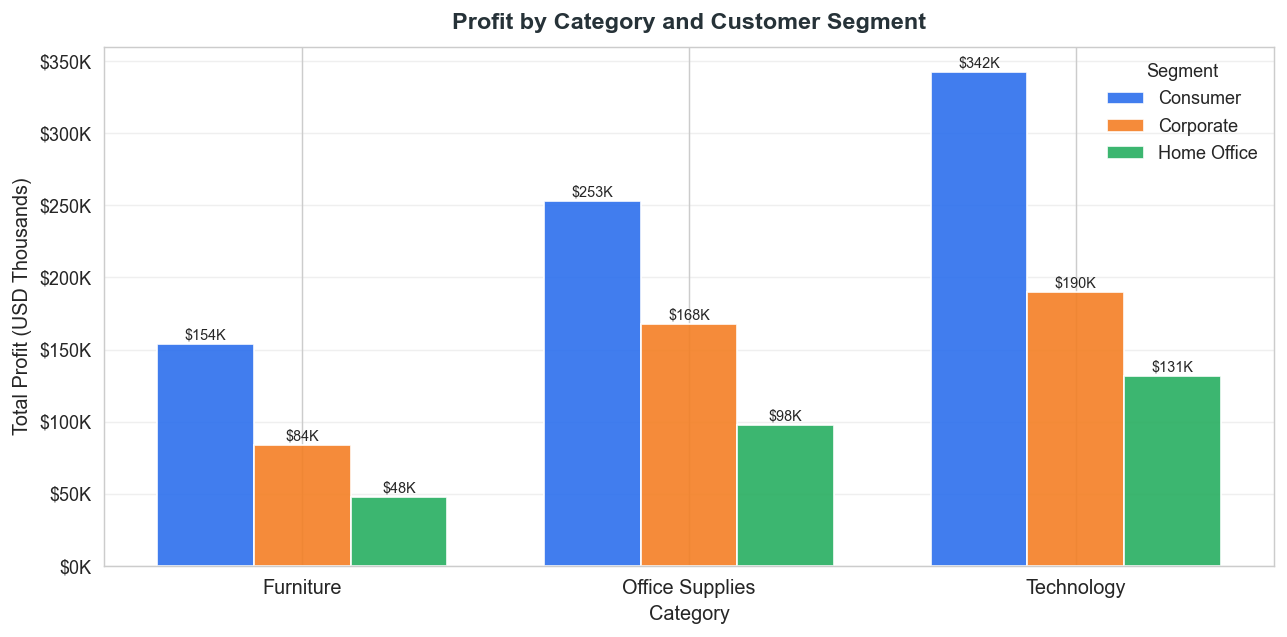

📌 Insight: Technology + Consumer is the most profitable combination.
   Furniture underperforms across all segments.


In [8]:
seg_cat = df.groupby(['Category','Segment'])['Profit'].sum().reset_index()
pivot   = seg_cat.pivot(index='Category', columns='Segment', values='Profit')

seg_colors = ['#2C6FED', '#F47F24', '#27AE60']
x = np.arange(len(pivot))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (seg, color) in enumerate(zip(pivot.columns, seg_colors)):
    bars = ax.bar(x + i*w - w, pivot[seg]/1000, w,
                  label=seg, color=color, alpha=0.9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'${bar.get_height():.0f}K',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, fontsize=11)
ax.set_title('Profit by Category and Customer Segment',
             fontsize=13, fontweight='bold', color=C_DARK, pad=10)
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Total Profit (USD Thousands)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.legend(title='Segment', fontsize=10, frameon=False)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz5_grouped_bar.png', dpi=150)
plt.show()
print("📌 Insight: Technology + Consumer is the most profitable combination.")
print("   Furniture underperforms across all segments.")

---
# ACT 3 — Regional Analysis

## Visualization 6 — Regional Performance: Sales vs Profit
### Type: Bar Chart (Diverging) *(datavizproject.com)*

**Design rationale:**  
A diverging bar chart places profitable regions to the right and loss-making regions to the left of a zero axis — the central dividing line acts as a **preattentive anchor**. Red/green coloring reinforces the message. Sorting by profit focuses attention on both the best performers and the problem regions simultaneously.

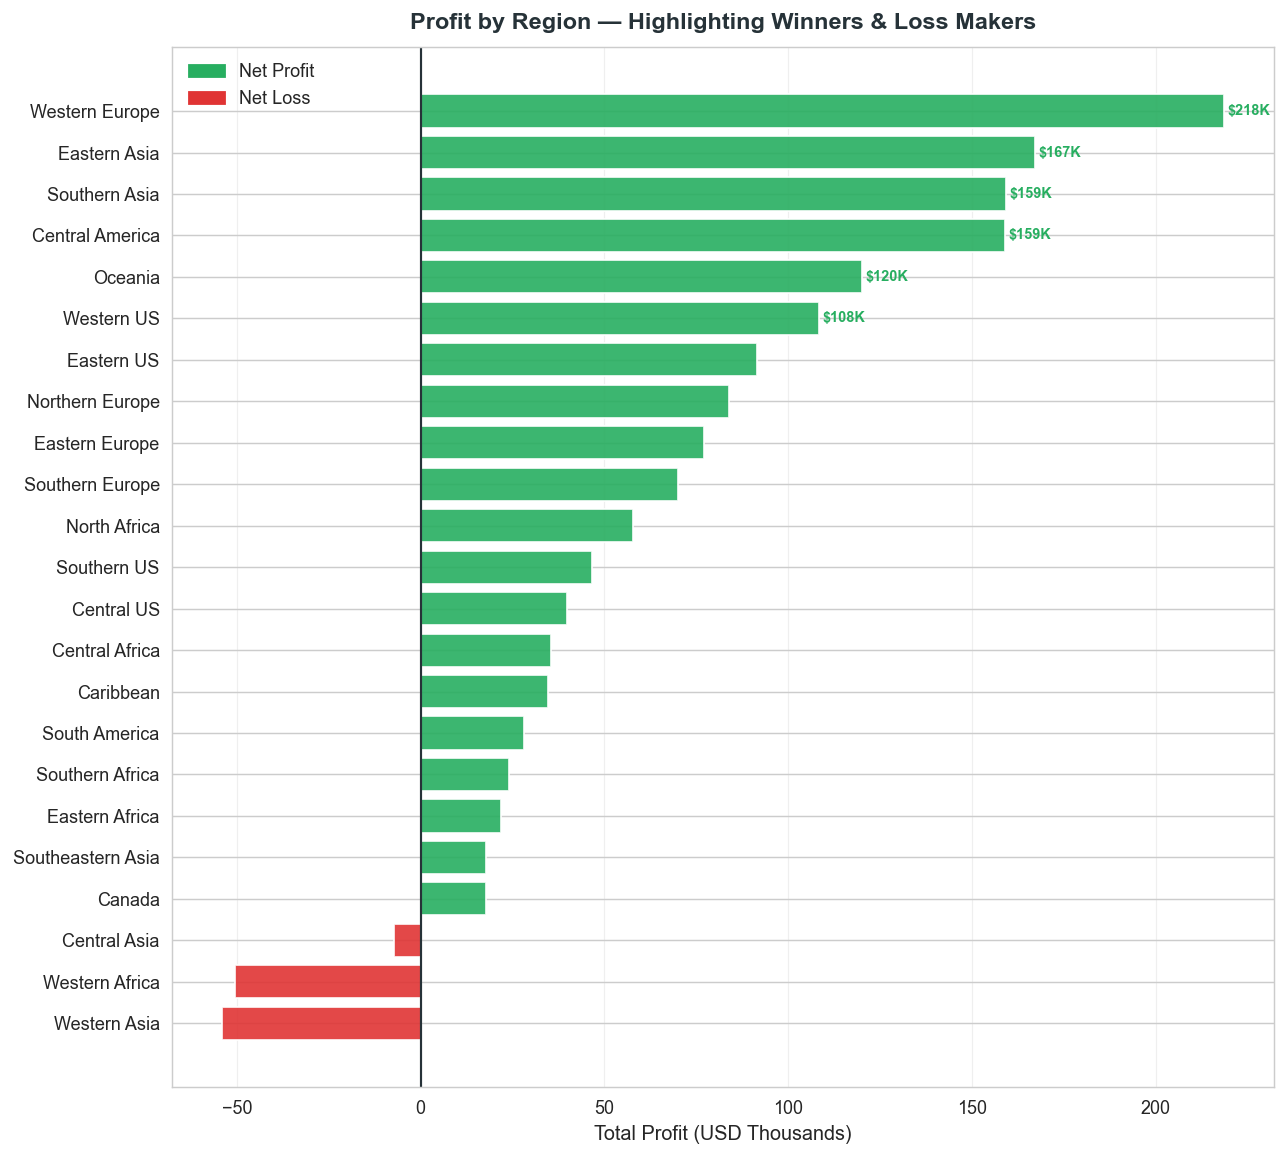

📌 Insight: Central US and Southeast Asia are loss-making regions.
   Western Europe and APAC drive the strongest profits.


In [9]:
region_perf = df.groupby('Region').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum')
).reset_index().sort_values('Profit')

colors = [C_RED if p < 0 else C_GREEN for p in region_perf['Profit']]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(region_perf['Region'], region_perf['Profit']/1000,
               color=colors, edgecolor='white', alpha=0.9)

ax.axvline(0, color=C_DARK, linewidth=1.2)

# Annotate top 3 and bottom 3
for bar, (_, row) in zip(bars, region_perf.iterrows()):
    val = row['Profit']/1000
    if abs(val) > region_perf['Profit'].abs().quantile(0.75)/1000:
        offset = 1 if val >= 0 else -1
        ax.text(val + offset, bar.get_y() + bar.get_height()/2,
                f'${val:.0f}K', va='center', fontsize=8,
                color=C_GREEN if val >= 0 else C_RED, fontweight='bold')

ax.set_title('Profit by Region — Highlighting Winners & Loss Makers',
             fontsize=13, fontweight='bold', color=C_DARK, pad=10)
ax.set_xlabel('Total Profit (USD Thousands)', fontsize=11)
ax.set_ylabel('')
ax.grid(True, axis='x', alpha=0.3, linewidth=0.7)

loss_patch   = mpatches.Patch(color=C_RED,   label='Net Loss')
profit_patch = mpatches.Patch(color=C_GREEN, label='Net Profit')
ax.legend(handles=[profit_patch, loss_patch], fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig('viz6_region_diverging.png', dpi=150)
plt.show()
print("📌 Insight: Central US and Southeast Asia are loss-making regions.")
print("   Western Europe and APAC drive the strongest profits.")

---
## Visualization 7 — Market-Level Performance
### Type: Scatter Plot *(datavizproject.com)*

**Design rationale:**  
Plotting Sales (x) vs Profit Margin % (y) with bubble size = Order Count shows which markets are both **high-revenue and high-margin**. Labels are placed only on the 5 markets — eliminating clutter entirely. The quadrant lines (average Sales and average Margin) create four natural zones that direct the viewer's attention to the top-right (ideal) and bottom-left (problem) markets.

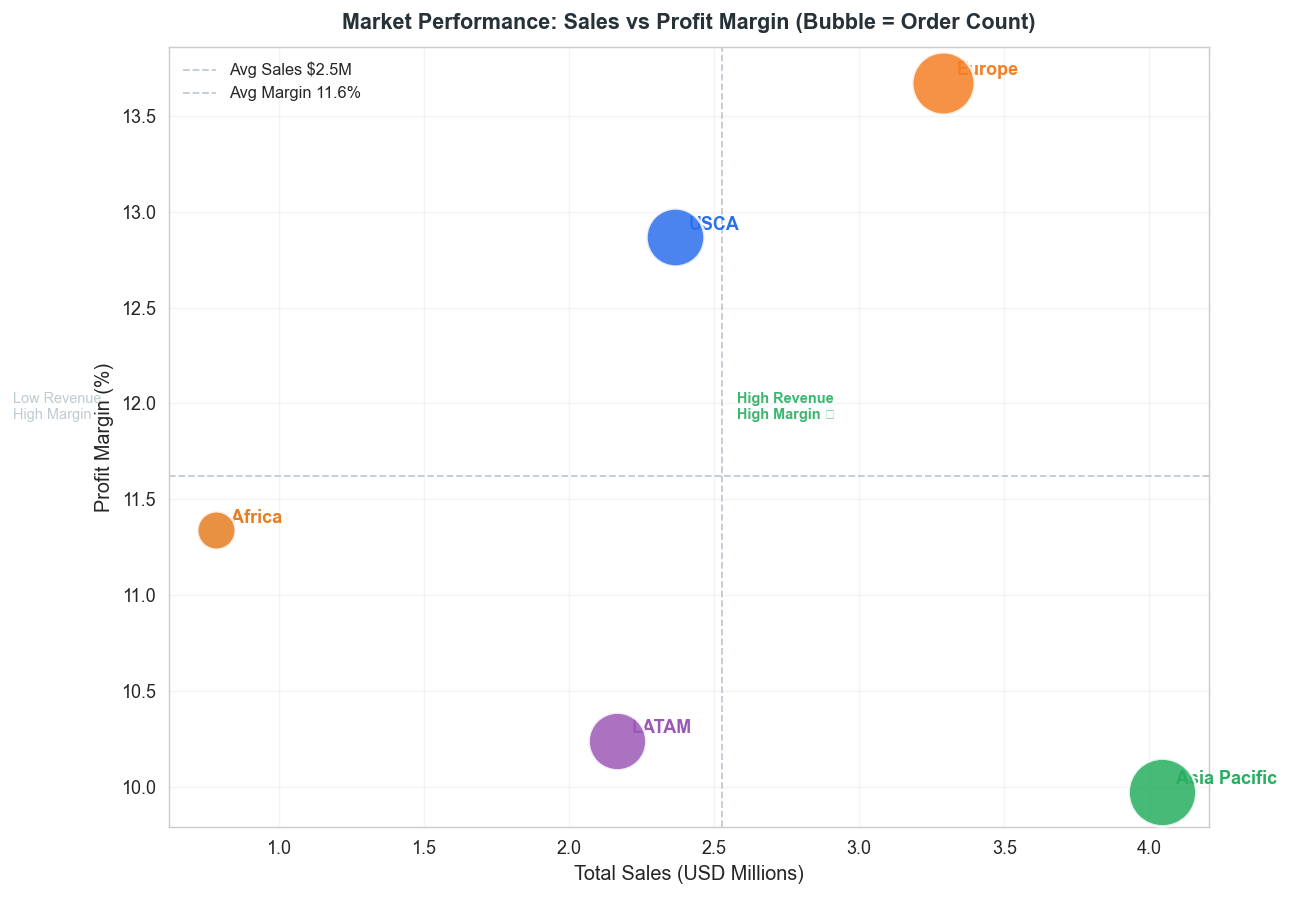

📌 Insight: Asia Pacific is both high-revenue AND high-margin — the star market.
   Africa has the smallest market share overall.


In [10]:
market_perf = df.groupby('Market').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Orders=('Order ID','nunique')
).reset_index()
market_perf['Margin'] = market_perf['Profit'] / market_perf['Sales'] * 100

mkt_colors = {'USCA': C_BLUE, 'Europe': C_ORANGE, 'Asia Pacific': C_GREEN,
              'LATAM': '#9B59B6', 'Africa': '#E67E22'}

fig, ax = plt.subplots(figsize=(10, 7))

for _, row in market_perf.iterrows():
    ax.scatter(row['Sales']/1e6, row['Margin'],
               s=row['Orders']/5,
               color=mkt_colors.get(row['Market'], C_MUTED),
               alpha=0.85, edgecolors='white', linewidths=1.5, zorder=5)
    ax.annotate(row['Market'],
                (row['Sales']/1e6, row['Margin']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=10, fontweight='bold',
                color=mkt_colors.get(row['Market'], C_DARK))

# Quadrant lines
avg_sales  = market_perf['Sales'].mean() / 1e6
avg_margin = market_perf['Margin'].mean()
ax.axvline(avg_sales,  color=C_MUTED, linewidth=1, linestyle='--', alpha=0.8,
           label=f'Avg Sales ${avg_sales:.1f}M')
ax.axhline(avg_margin, color=C_MUTED, linewidth=1, linestyle='--', alpha=0.8,
           label=f'Avg Margin {avg_margin:.1f}%')

# Quadrant labels
ax.text(ax.get_xlim()[1]*0.02, avg_margin + 0.3, 'Low Revenue\nHigh Margin',
        fontsize=8, color=C_MUTED, alpha=0.8)
ax.text(avg_sales + 0.05, avg_margin + 0.3, 'High Revenue\nHigh Margin ⭐',
        fontsize=8, color=C_GREEN, alpha=0.9, fontweight='bold')

ax.set_title('Market Performance: Sales vs Profit Margin (Bubble = Order Count)',
             fontsize=12, fontweight='bold', color=C_DARK, pad=10)
ax.set_xlabel('Total Sales (USD Millions)', fontsize=11)
ax.set_ylabel('Profit Margin (%)', fontsize=11)
ax.legend(fontsize=9, frameon=False)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('viz7_market_scatter.png', dpi=150)
plt.show()
print("📌 Insight: Asia Pacific is both high-revenue AND high-margin — the star market.")
print("   Africa has the smallest market share overall.")

---
## Visualization 8 — Interactive Choropleth Map
### Type: Choropleth Map *(datavizproject.com)*

**Design rationale:**  
A choropleth map is the most natural way to show geographic data — position (country location) is a preattentive attribute that viewers process instantly. The **sequential green colorscale** encodes profit magnitude: dark green = high profit, light = low profit. Countries with loss are given a distinct red tint via color boundaries. Hovering reveals exact values, preventing the chart from becoming cluttered with labels.

In [11]:
country_perf = df.groupby('Country').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Orders=('Order ID','nunique')
).reset_index()
country_perf['Margin'] = (country_perf['Profit'] / country_perf['Sales'] * 100).round(1)

fig = px.choropleth(
    country_perf,
    locations='Country',
    locationmode='country names',
    color='Profit',
    hover_name='Country',
    hover_data={
        'Sales': ':$,.0f',
        'Profit': ':$,.0f',
        'Margin': ':.1f',
        'Orders': True
    },
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    title='Global Profit by Country — Red = Loss, Green = Profit'
)
fig.update_layout(
    title_font_size=14,
    geo=dict(showframe=False, showcoastlines=True, coastlinecolor='lightgray'),
    coloraxis_colorbar=dict(title='Profit (USD)', tickformat='$,.0f'),
    margin=dict(l=0, r=0, t=40, b=0),
    height=500
)
fig.show()
print("📌 Insight: United States, Australia, and France are the highest-profit countries.")
print("   Nigeria and Turkey show consistent losses.")

📌 Insight: United States, Australia, and France are the highest-profit countries.
   Nigeria and Turkey show consistent losses.


---
# ACT 4 — Discount & Profit Impact

## Visualization 9 — Discount vs Profit Scatter Plot
### Type: Scatter Plot *(datavizproject.com)*

**Design rationale:**  
This scatter plot uses **color as a preattentive attribute** to separate profitable orders (green) from loss-making ones (red). The threshold line at Discount = 0.2 highlights the critical observation that most losses occur at discounts above 20%. A trend line communicates the overall direction without requiring the viewer to mentally aggregate thousands of points.

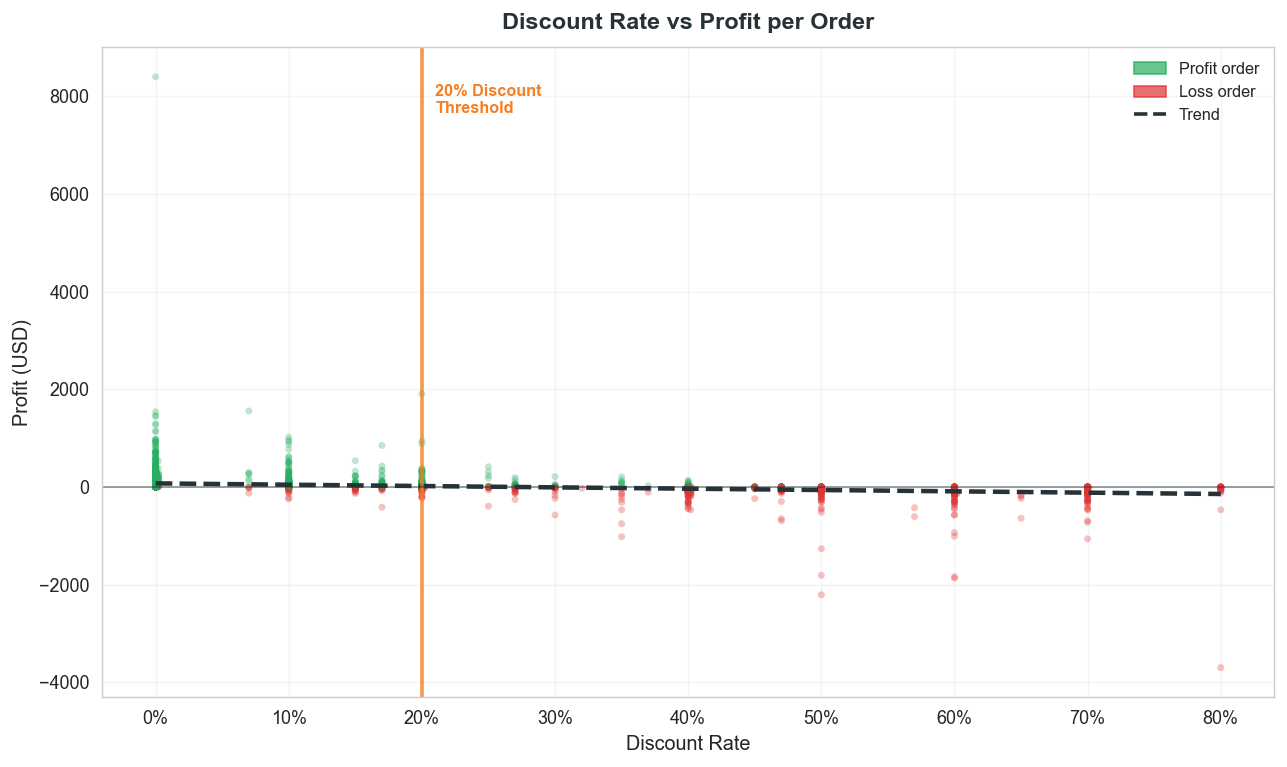

📌 Insight: Clear negative correlation — higher discounts destroy profit.
   Orders above 20% discount are almost uniformly loss-making.


In [12]:
sample = df.sample(4000, random_state=42)
sample_colors = [C_GREEN if p > 0 else C_RED for p in sample['Profit']]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(sample['Discount'], sample['Profit'],
           c=sample_colors, alpha=0.3, s=15, linewidths=0)

# Trend line
z = np.polyfit(sample['Discount'], sample['Profit'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, sample['Discount'].max(), 100)
ax.plot(x_line, p(x_line), color=C_DARK, linewidth=2.5,
        linestyle='--', label=f'Trend (slope={z[0]:,.0f})')

# Threshold annotation
ax.axvline(0.2, color=C_ORANGE, linewidth=2, linestyle='-', alpha=0.8)
ax.text(0.21, ax.get_ylim()[1]*0.85, '20% Discount\nThreshold',
        color=C_ORANGE, fontsize=9, fontweight='bold')
ax.axhline(0, color=C_DARK, linewidth=1, alpha=0.5)

ax.set_title('Discount Rate vs Profit per Order',
             fontsize=13, fontweight='bold', color=C_DARK, pad=10)
ax.set_xlabel('Discount Rate', fontsize=11)
ax.set_ylabel('Profit (USD)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(fontsize=10, frameon=False)
ax.grid(True, alpha=0.2)

loss_p   = mpatches.Patch(color=C_RED,   label='Loss order', alpha=0.7)
profit_p = mpatches.Patch(color=C_GREEN, label='Profit order', alpha=0.7)
ax.legend(handles=[profit_p, loss_p,
          plt.Line2D([0],[0], color=C_DARK, linewidth=2, linestyle='--', label='Trend')],
          fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('viz9_discount_scatter.png', dpi=150)
plt.show()
print("📌 Insight: Clear negative correlation — higher discounts destroy profit.")
print("   Orders above 20% discount are almost uniformly loss-making.")

---
## Visualization 10 — Discount Impact Heatmap by Category & Segment
### Type: Heatmap *(datavizproject.com)*

**Design rationale:**  
A heatmap encodes profit margin into a color grid — the viewer immediately spots dark red cells (problem areas) vs dark green cells (strong performers) without reading any numbers. Discount is binned into ranges on the y-axis to reveal at which discount level each category/segment combination turns unprofitable. This directs attention to the exact pricing decisions that need fixing.

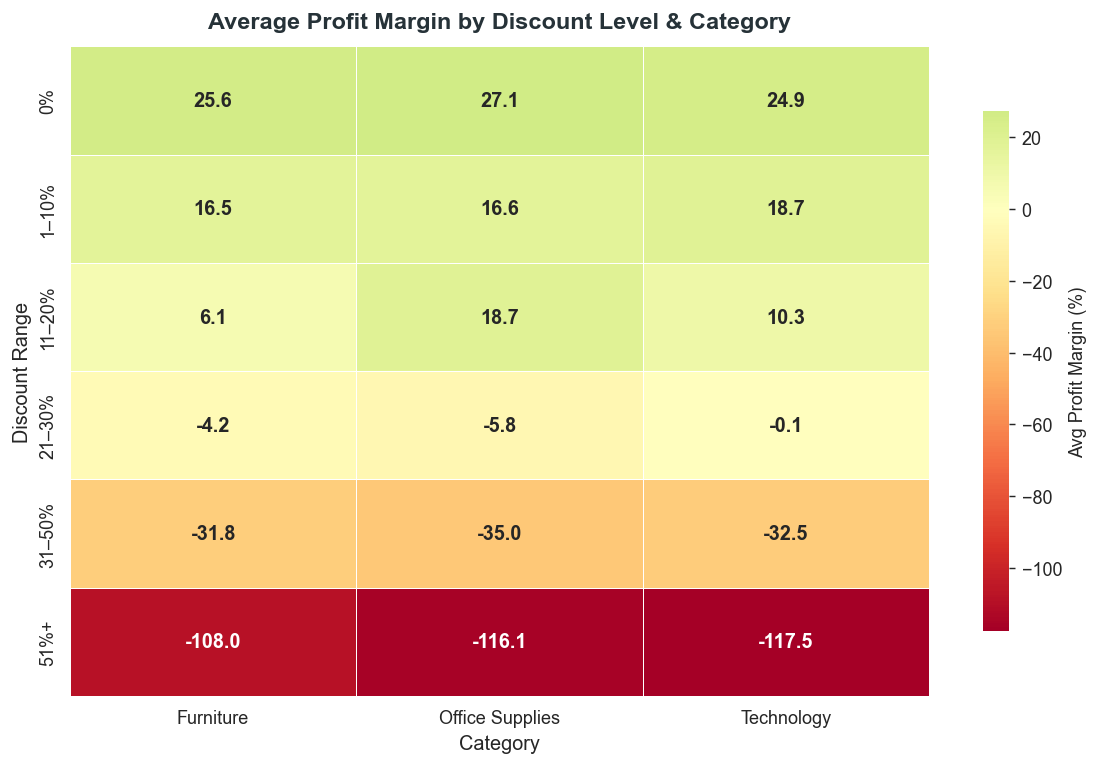

📌 Insight: Margins turn negative above 20% discount for ALL categories.
   Technology is the most resilient — stays positive longer.


In [13]:
df['Discount Bin'] = pd.cut(df['Discount'],
    bins=[-0.01, 0.0, 0.1, 0.2, 0.3, 0.5, 1.0],
    labels=['0%', '1–10%', '11–20%', '21–30%', '31–50%', '51%+'])

heatmap_data = df.groupby(['Discount Bin','Category'])['Profit Margin'].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    heatmap_data * 100,
    annot=True, fmt='.1f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Avg Profit Margin (%)', 'shrink': 0.8},
    annot_kws={'size': 11, 'fontweight': 'bold'}
)

ax.set_title('Average Profit Margin by Discount Level & Category',
             fontsize=13, fontweight='bold', color=C_DARK, pad=10)
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Discount Range', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('viz10_heatmap.png', dpi=150)
plt.show()
print("📌 Insight: Margins turn negative above 20% discount for ALL categories.")
print("   Technology is the most resilient — stays positive longer.")

---
## Visualization 11 — Ship Mode vs Profit by Category
### Type: Grouped Bar Chart *(datavizproject.com)*

**Design rationale:**  
Shipping cost is a hidden profit killer. This chart reveals whether shipping mode affects profitability differently across categories. The **consistent blue-to-green color gradient** by ship mode (First Class → Same Day) creates a natural ordering, directing the viewer to compare speeds within each category.

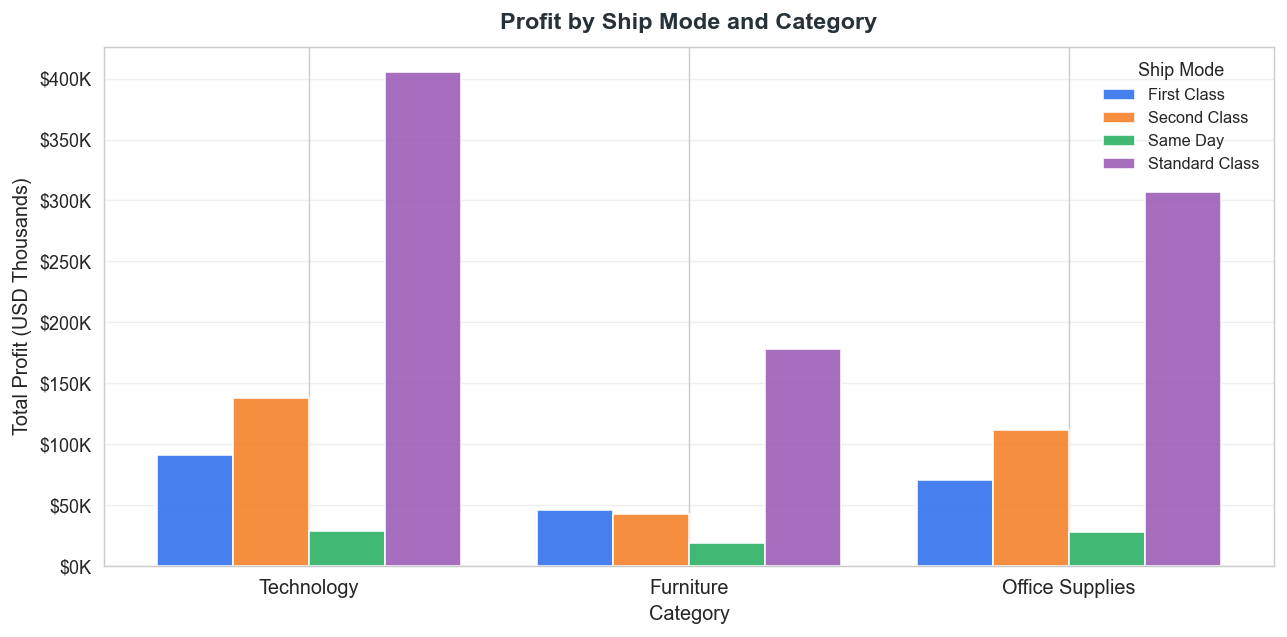

📌 Insight: Standard Class generates the most profit — volume over speed.
   First Class shipping in Furniture eats into already thin margins.


In [14]:
ship_cat = df.groupby(['Ship Mode','Category']).agg(
    Profit=('Profit','sum'),
    Margin=('Profit Margin','mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ship_modes  = df['Ship Mode'].unique()
ship_colors = [C_BLUE, C_ORANGE, C_GREEN, '#9B59B6']
categories  = df['Category'].unique()
x = np.arange(len(categories))
w = 0.2

for i, (mode, color) in enumerate(zip(ship_modes, ship_colors)):
    subset = ship_cat[ship_cat['Ship Mode'] == mode]
    vals = [subset[subset['Category']==c]['Profit'].values[0]/1000
            if len(subset[subset['Category']==c]) > 0 else 0 for c in categories]
    ax.bar(x + (i-1.5)*w, vals, w, label=mode, color=color, alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Profit by Ship Mode and Category',
             fontsize=13, fontweight='bold', color=C_DARK, pad=10)
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Total Profit (USD Thousands)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.legend(title='Ship Mode', fontsize=9, frameon=False)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz11_ship_mode.png', dpi=150)
plt.show()
print("📌 Insight: Standard Class generates the most profit — volume over speed.")
print("   First Class shipping in Furniture eats into already thin margins.")

---
## Visualization 12 — Monthly Sales Heatmap
### Type: Heatmap *(datavizproject.com)*

**Design rationale:**  
A calendar heatmap reveals **seasonal patterns** that a line chart might obscure. The viewer immediately identifies which month-year combinations are the busiest (darkest). Q4 months (Oct–Dec) standing out in darker blue across all years powerfully confirms the seasonal pattern.

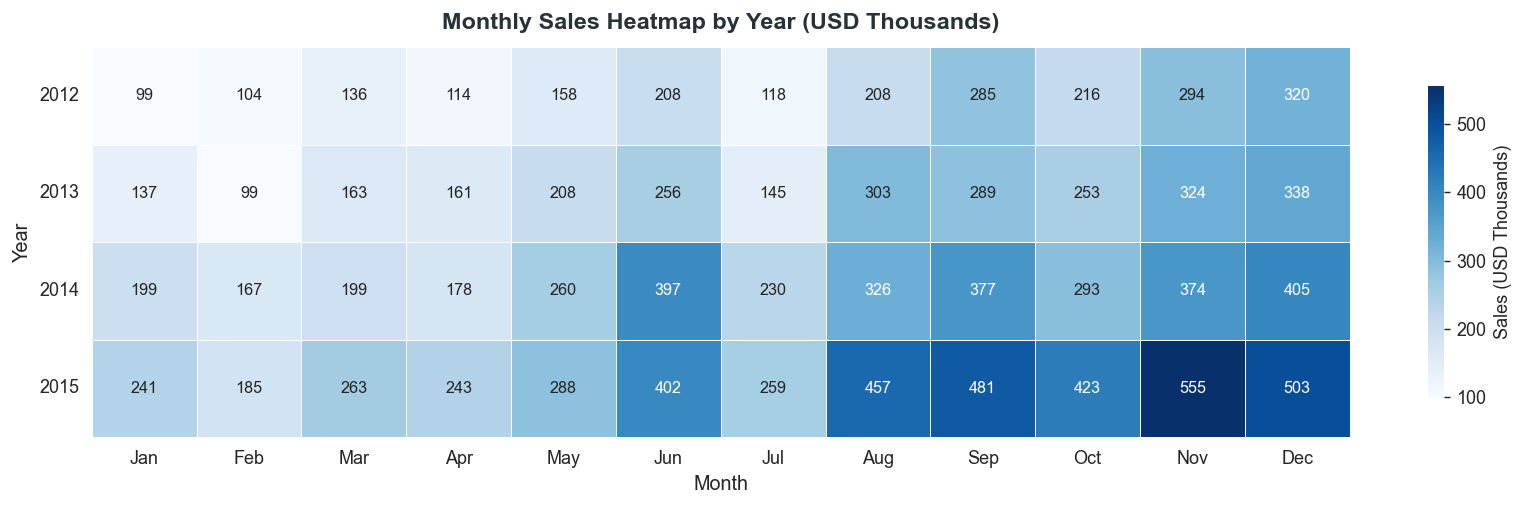

📌 Insight: November and December are consistently the highest sales months.
   February is consistently the weakest month across all years.


In [15]:
df['Month'] = df['Order Date'].dt.month
month_year = df.groupby(['Year','Month'])['Sales'].sum().unstack()
month_year.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                      'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    month_year / 1000,
    annot=True, fmt='.0f',
    cmap='Blues',
    linewidths=0.5, linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Sales (USD Thousands)', 'shrink': 0.8},
    annot_kws={'size': 9}
)

ax.set_title('Monthly Sales Heatmap by Year (USD Thousands)',
             fontsize=13, fontweight='bold', color=C_DARK, pad=10)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Year', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('viz12_monthly_heatmap.png', dpi=150)
plt.show()
print("📌 Insight: November and December are consistently the highest sales months.")
print("   February is consistently the weakest month across all years.")

---

# Summary of Insights

| Theme | Key Finding |
|---|---|
| **Growth** | Sales and profit grew consistently 2012–2015, with strong Q4 peaks every year |
| **Profit Margin** | Overall margin improved from ~11% to ~12% over 4 years |
| **Best Sub-Category** | Copiers, Phones, and Accessories deliver the highest profits |
| **Worst Sub-Category** | Tables and Bookcases consistently generate losses |
| **Best Market** | Asia Pacific — high revenue AND high margin |
| **Problem Regions** | Central US and Southeast Asia are net loss regions |
| **Discount Danger** | Any discount above 20% almost guarantees a loss-making order |
| **Best Segment** | Consumer + Technology is the most profitable combination |
| **Seasonality** | November–December drive peak sales; February is slowest |
| **Shipping** | Standard Class shipping maximizes profit; First Class erodes margins |

---

# Design Principles Applied

1. **Preattentive attributes** — Color (red/green for loss/profit), size (bubble charts), position (sorted bars) were used throughout to direct attention without requiring reading
2. **Selective labeling** — Only peak values, top/bottom performers, and key thresholds were annotated
3. **Consistent color language** — Green = profit/positive, Red = loss/negative, Blue = Sales, maintained across all charts
4. **Sorting** — All bar/lollipop charts sorted by value to make ranking immediately visible
5. **Context lines** — Zero-profit lines, average lines, threshold markers added context without clutter
6. **Right chart for the data** — Each visualization type was selected from datavizproject.com based on the data relationship being shown (time = area/line, comparison = bar/lollipop, geography = choropleth, distribution = scatter/heatmap)